# AMASE-P Scheduling — Interactive Demo

Step-by-step walkthrough of the standard workflow (the notebook twin of `example/demo.py`):

1. **Load** the target list (with input validation)
2. **Load** the shipped visibility cache (build a fresh one if missing)
3. **Single-night** schedule (reuses the cache)
4. **Multi-night campaign** 2027-04-01 .. 2027-04-15 with a weather model
5. **Export** the observing log (text + CSV trio) and all figures

Everything is written to `example/outputs/`. The same results can be produced from the CLI;
the equivalent commands are shown at the end.


In [1]:
from pathlib import Path
import time

import pandas as pd
from IPython.display import Image, display

from amase_scheduling import (
    Scheduler,
    VisibilityCache,
    format_report,
    load_targets,
    plot_campaign_figure,
    plot_night_figure,
    save_all_night_figures,
    save_nights_csv,
    save_schedule_csv,
    save_targets_csv,
)
from amase_scheduling._warnings import suppress_future_date_warnings

suppress_future_date_warnings()

# Locate the repo root (works whether the kernel starts in the repo or in example/)
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "example" / "targets.csv").exists())
TARGETS = REPO / "example" / "targets.csv"
OUTDIR = REPO / "example" / "outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)

START, END = "2027-04-01", "2027-04-15"
CLEAR_PROB = 0.5
SEED = 2027
WORKERS = 8


## Step 1 — Load the target list

`load_targets` parses the CSV and validates every row (missing fields, coordinate forms,
`exp_time <= 3600`, `n_dither` in {1, 3, 9, 27}, `n_set >= 1`; a missing `group` becomes
`"Untitle"`). The schedulable unit is a **single exposure** of `exp_time` seconds; the
season-total demand is `n_dither × n_set` exposures, accumulated flexibly across nights.


In [2]:
targets = load_targets(str(TARGETS))

overview = pd.DataFrame(
    {
        "name": t.name,
        "ra_deg": round(t.coord.ra.deg, 4),
        "dec_deg": round(t.coord.dec.deg, 4),
        "priority": t.priority,
        "exp_min": round(t.exp_time / 60, 1),
        "n_dither": t.n_dither,
        "n_set": t.n_set,
        "exposures": t.n_exposures,
        "total_h": round(t.total_time_sec / 3600, 2),
        "group": t.group,
    }
    for t in targets
)
print(f"{len(targets)} targets, {overview['exposures'].sum()} exposures, "
      f"{overview['total_h'].sum():.1f} h total demand, {overview['group'].nunique()} groups")
overview


42 targets, 1621 exposures, 440.6 h total demand, 11 groups


,name,ra_deg,dec_deg,priority,exp_min,n_dither,n_set,exposures,total_h,group
0,WR7,109.6214,-13.2171,1.0,33.3,9,1,9,5.00,Eric Liang
1,WR116,276.7679,-12.3813,1.0,60.0,9,1,9,9.00,Eric Liang
2,WR131,300.0797,33.2642,1.0,20.0,1,3,3,1.00,Eric Liang
3,WR124,287.8786,16.8606,1.0,7.5,1,3,3,0.38,Eric Liang
4,WR128-1,297.1342,18.2010,1.0,1.0,1,3,3,0.05,Eric Liang
5,WR128-2,297.1342,18.2010,1.0,25.0,9,1,9,3.75,Eric Liang
6,Rosette nebula,97.9583,4.9983,1.0,12.0,9,6,54,10.80,Xihan Ji
7,NGC6888,303.0292,38.3550,1.0,12.0,9,1,9,1.80,Xihan Ji
8,Westerhout50,287.9542,4.9867,1.0,15.0,9,4,36,9.00,Xihan Ji
9,Zeta-Oph,249.2875,-10.5678,1.0,15.0,3,1,3,0.75,Lin lin


## Step 2 — Load the visibility cache

Visibility (altitude / Sun / Moon per 5-min slot, valid exposure-start slots, transit-quality
factor) is independent of weather and scheduling state, so it is precomputed **once** and
reused by any number of scheduling runs. The repo ships `example/vis_cache.npz` covering
**2027-04-01 .. 2029-04-01** for the example target list — load it directly. If it is missing
(e.g. you edited the target list), build a fresh one in parallel. The cache is bound to the
target list (names + order); a requested night outside the covered range raises a clear error.


In [3]:
SHIPPED_CACHE = REPO / "example" / "vis_cache.npz"

t0 = time.perf_counter()
if SHIPPED_CACHE.exists():
    cache = VisibilityCache.load(str(SHIPPED_CACHE))
    print(f"loaded {len(cache)} nights ({min(cache.nights)} .. {max(cache.nights)}) "
          f"from {SHIPPED_CACHE} in {time.perf_counter() - t0:.1f}s")
else:
    cache = VisibilityCache.build(targets, START, END, n_workers=WORKERS)
    cache.save(str(OUTDIR / "vis_cache.npz"))
    print(f"cached {len(cache)} nights in {time.perf_counter() - t0:.1f}s -> {OUTDIR / 'vis_cache.npz'}")


loaded 732 nights (2027-04-01 .. 2029-04-01) from /home/chengz/Code/opencode/AMASE_scheduling/example/vis_cache.npz in 0.4s


## Step 3 — Single-night schedule

A single night is a degenerate campaign: one date, `clear_prob = 1.0` (no weather dice), full
exposure demand. The same engine and the same unified report serve both cases — for one night
the night section expands into the full block table.


In [4]:
scheduler = Scheduler()
night_result = scheduler.schedule(targets, START, visibility_cache=cache)
print(format_report(night_result))

AMASE-P Observing Campaign Report
Period: 2027-04-01 to 2027-04-01 (1 nights)
Weather model: 100% clear probability (seed=None)

Night 2027-04-01 (clear):
          target  exposure         obs_start_utc           obs_end_utc          lst  duration_min  altitude_deg  azimuth_deg  moon_sep_deg
----------------  --------  --------------------  --------------------  -----------  --------  --------  --------  ----------
             M82         1  2027-04-01T13:42:35.452  2027-04-01T14:42:35.452  08:10-09:10      60.0      62.1      14.4       128.5
             M82         2  2027-04-01T14:42:35.452  2027-04-01T15:42:35.452  09:10-10:10      60.0      63.8       3.5       128.4
             M82         3  2027-04-01T15:42:35.452  2027-04-01T16:42:35.452  10:10-11:11      60.0      63.4     351.8       128.3
             M82         4  2027-04-01T16:42:35.452  2027-04-01T17:42:35.452  11:11-12:11      60.0      60.8     341.9       128.2
             M82         5  2027-04-01T17:42:35.452 

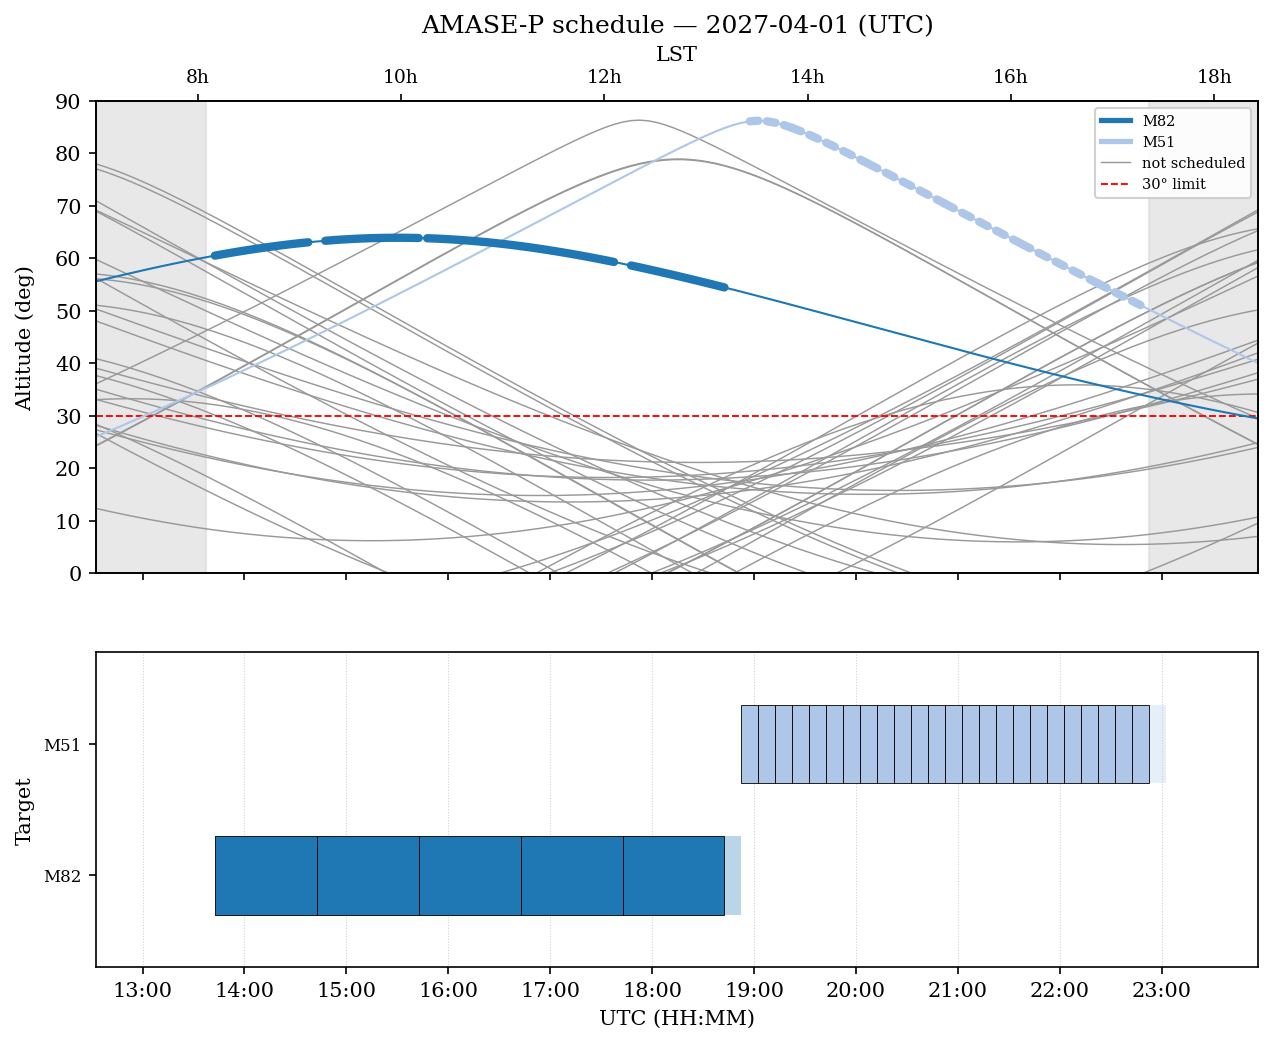

In [5]:
night_png = OUTDIR / f"night_{START}.png"
plot_night_figure(night_result.nights[0], targets, scheduler.observer, str(night_png))
display(Image(filename=str(night_png)))

## Step 4 — Multi-night campaign with weather

Each night is independently clear with probability `clear_prob` (Bernoulli, seeded). Every
scheduled exposure decrements its target's `remaining` counter; completed targets graduate.
The engine is serial across nights — per-night MILPs are exact here because exposures never
span nights and no inter-night constraints exist (see DESIGN.md §8.4).


In [6]:
result = scheduler.schedule(
    targets, START, END,
    clear_prob=CLEAR_PROB, seed=SEED,
    visibility_cache=cache, verbose=True,
)
report = format_report(result)
print(report)

2027-04-01: 29 blocks, 540 min


2027-04-02: 14 blocks, 525 min


2027-04-03: 19 blocks, 535 min


2027-04-04: 9 blocks, 540 min


2027-04-05: 14 blocks, 525 min
2027-04-06: cloudy


2027-04-07: 38 blocks, 470 min
2027-04-08: cloudy
2027-04-09: cloudy


2027-04-10: 13 blocks, 325 min


2027-04-11: 27 blocks, 305 min


2027-04-12: 22 blocks, 225 min
2027-04-13: cloudy


2027-04-14: 29 blocks, 245 min
2027-04-15: cloudy
AMASE-P Observing Campaign Report
Period: 2027-04-01 to 2027-04-15 (15 nights)
Weather model: 50% clear probability (seed=2027)
** CAPACITY WARNING: total demand 29288 min exceeds expected available 5379 min (15 nights x 717 min x 50% clear). Some targets will not complete.

Per-night summary (clear nights with observations):
date          blocks   hours  targets
----------------------------------------
2027-04-01        29     9.0        2
2027-04-02        14     8.7        3
2027-04-03        19     8.9        2
2027-04-04         9     9.0        1
2027-04-05        14     8.7        2
2027-04-07        38     7.8        7
2027-04-10        13     5.4        4
2027-04-11        27     5.1        4
2027-04-12        22     3.8        6
2027-04-14        29     4.1        3

Target completion:
target                done   req   frac  nights   hours
------------------------------------------------------------
… (22 least-complete targe

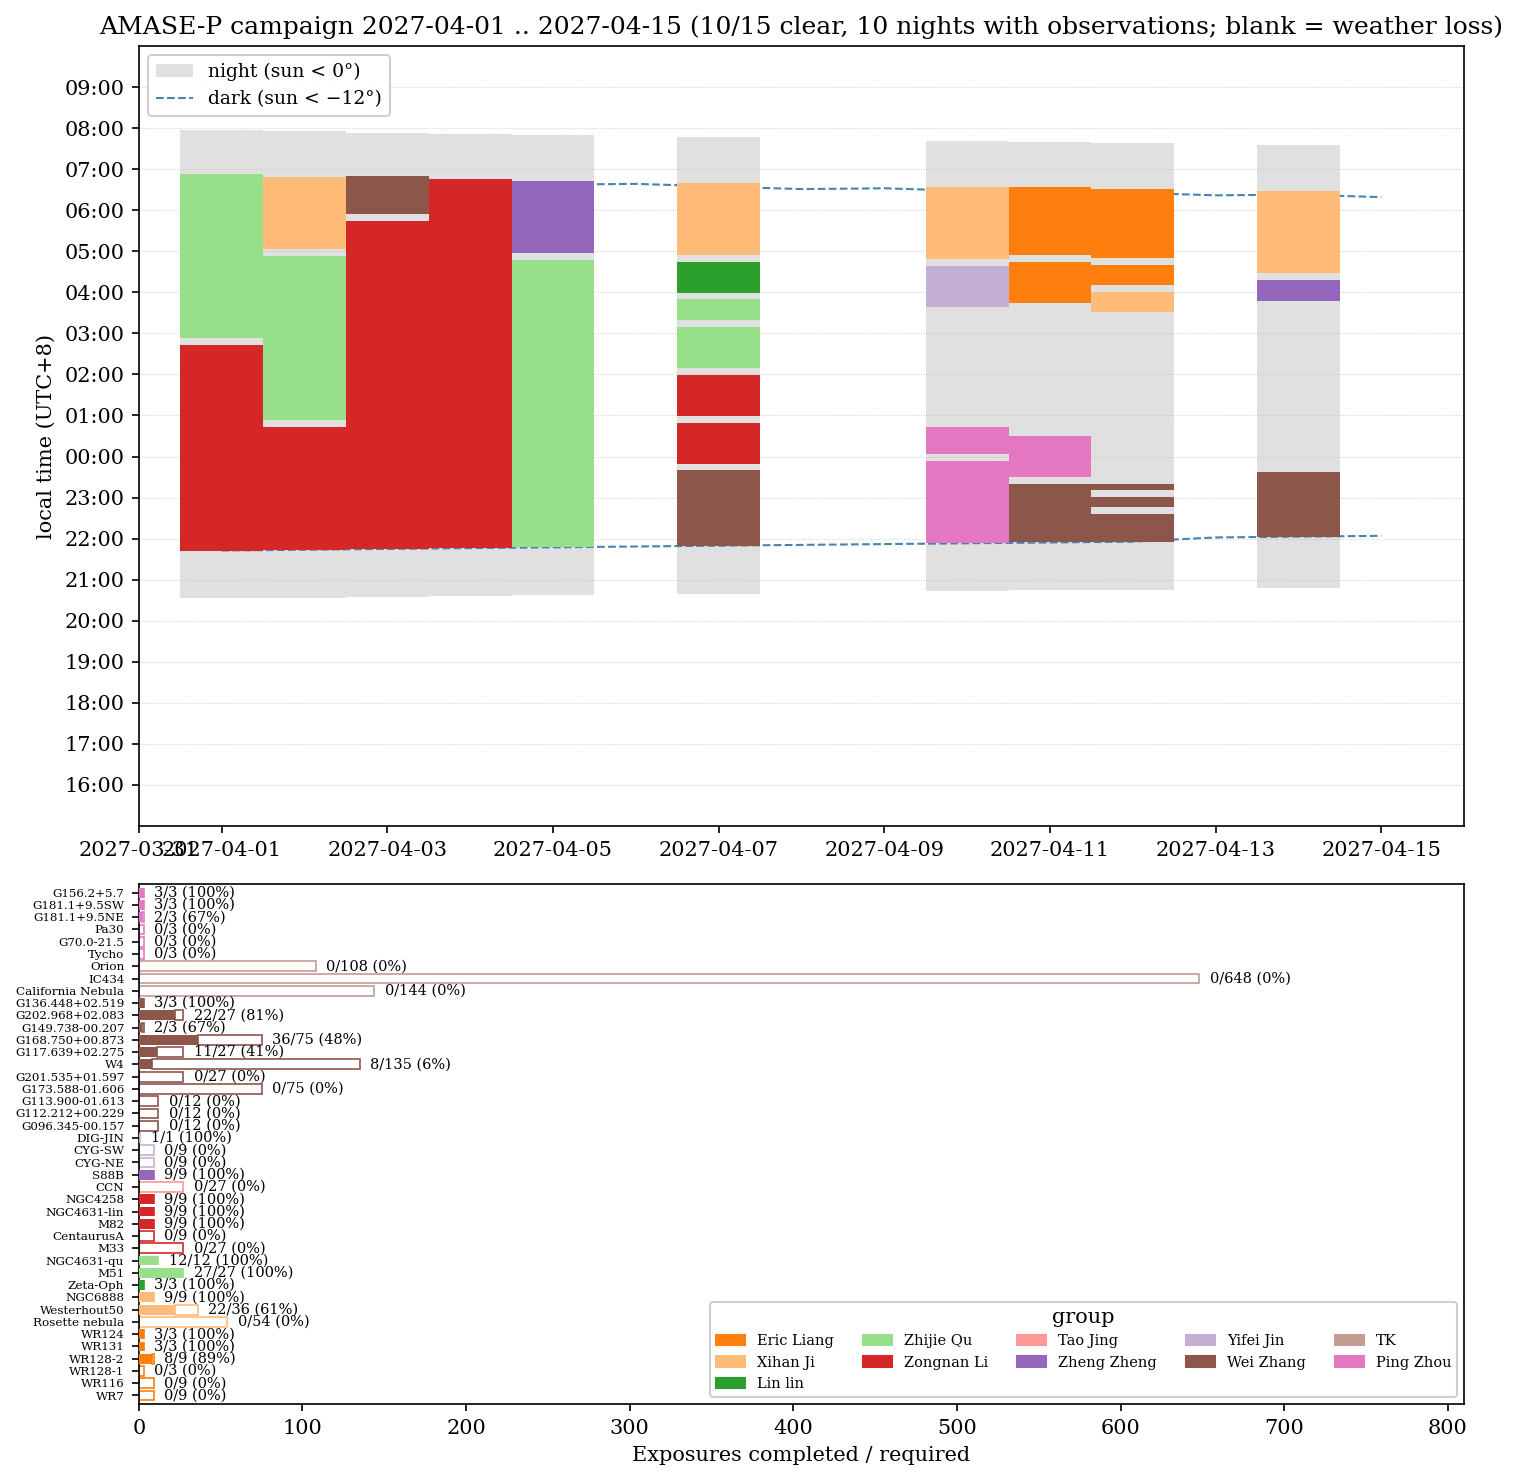

In [7]:
campaign_png = OUTDIR / "campaign.png"
plot_campaign_figure(result, str(campaign_png), targets=targets, observer=scheduler.observer)
display(Image(filename=str(campaign_png)))

## Step 5 — Export the observing log and figures

The CSV trio (`observing_log.csv` + `_targets.csv` + `_nights.csv`) is the complete interchange
format — `amase-plot` can re-render every figure from these files alone, without re-running
the scheduler.

In [8]:
(OUTDIR / "observing_log.txt").write_text(report + "\n")
save_schedule_csv(result, str(OUTDIR / "observing_log.csv"))
save_targets_csv(result, str(OUTDIR / "observing_log_targets.csv"))
save_nights_csv(result, str(OUTDIR / "observing_log_nights.csv"))
night_paths = save_all_night_figures(result, targets, scheduler.observer, str(OUTDIR / "nights"))
print(f"CSV trio + report + {len(night_paths)} night figures written to {OUTDIR}")
pd.read_csv(OUTDIR / "observing_log.csv").head(10)

CSV trio + report + 10 night figures written to /home/chengz/Code/opencode/AMASE_scheduling/example/outputs


,date,target,exposure,obs_start_utc,obs_end_utc,obs_start_local,obs_end_local,lst_start,lst_end,duration_min,altitude_deg,azimuth_deg,moon_sep_deg
0,2027-04-01,M82,1,2027-04-01T13:42:35.452,2027-04-01T14:42:35.452,2027-04-01 21:42:35,2027-04-01 22:42:35,08:10,09:10,60.0,62.1,14.4,128.5
1,2027-04-01,M82,2,2027-04-01T14:42:35.452,2027-04-01T15:42:35.452,2027-04-01 22:42:35,2027-04-01 23:42:35,09:10,10:10,60.0,63.8,3.5,128.4
2,2027-04-01,M82,3,2027-04-01T15:42:35.452,2027-04-01T16:42:35.452,2027-04-01 23:42:35,2027-04-02 00:42:35,10:10,11:11,60.0,63.4,351.8,128.3
3,2027-04-01,M82,4,2027-04-01T16:42:35.452,2027-04-01T17:42:35.452,2027-04-02 00:42:35,2027-04-02 01:42:35,11:11,12:11,60.0,60.8,341.9,128.2
4,2027-04-01,M82,5,2027-04-01T17:42:35.452,2027-04-01T18:42:35.452,2027-04-02 01:42:35,2027-04-02 02:42:35,12:11,13:11,60.0,56.8,335.4,128.2
5,2027-04-01,M51,1,2027-04-01T18:52:35.452,2027-04-01T19:02:35.452,2027-04-02 02:52:35,2027-04-02 03:02:35,13:21,13:31,10.0,86.1,12.8,118.4
6,2027-04-01,M51,2,2027-04-01T19:02:35.452,2027-04-01T19:12:35.452,2027-04-02 03:02:35,2027-04-02 03:12:35,13:31,13:41,10.0,86.1,347.6,118.5
7,2027-04-01,M51,3,2027-04-01T19:12:35.452,2027-04-01T19:22:35.452,2027-04-02 03:12:35,2027-04-02 03:22:35,13:41,13:51,10.0,85.4,326.6,118.5
8,2027-04-01,M51,4,2027-04-01T19:22:35.452,2027-04-01T19:32:35.452,2027-04-02 03:22:35,2027-04-02 03:32:35,13:51,14:01,10.0,84.2,313.0,118.6
9,2027-04-01,M51,5,2027-04-01T19:32:35.452,2027-04-01T19:42:35.452,2027-04-02 03:32:35,2027-04-02 03:42:35,14:01,14:11,10.0,82.8,304.7,118.6


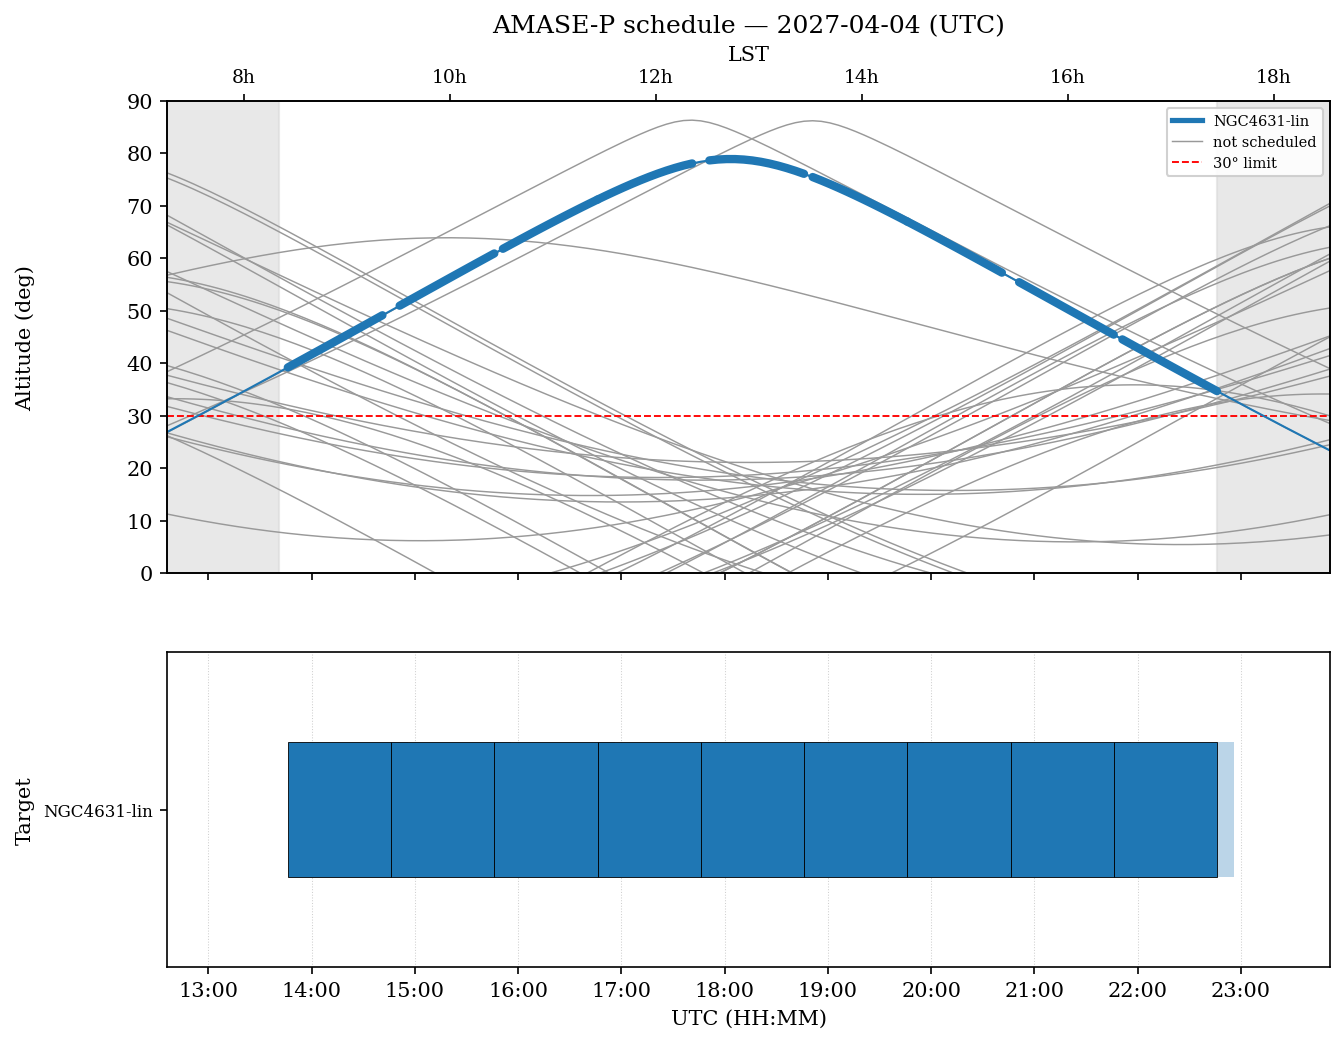

In [9]:
# One of the per-night duty figures
display(Image(filename=night_paths[3]))

## Equivalent CLI session

```bash
# The shipped cache covers 2027-04-01 .. 2029-04-01 for example/targets.csv —
# no precompute needed inside that range. (For other lists or date ranges:
# amase-precompute targets.csv --start ... --end ... --workers 8 -o my_cache.npz)

amase-schedule example/targets.csv 2027-04-01 --cache example/vis_cache.npz \
    -o example/outputs/night.csv

amase-schedule example/targets.csv --start 2027-04-01 --end 2027-04-15 \
    --clear-prob 0.5 --seed 2027 --cache example/vis_cache.npz \
    -o example/outputs/observing_log.csv -v

amase-plot campaign example/outputs/observing_log.csv --targets example/targets.csv \
    -o example/outputs/campaign.png
amase-plot nights example/outputs/observing_log.csv --targets example/targets.csv \
    -o example/outputs/nights/
```
